C:\Users\mihre\AppData\Local\Temp\ipykernel_13212\1873190940.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  brent_df = pd.read_csv("../data/BrentOilPrices.csv", parse_dates=["Date"], dayfirst=True)


✔ Data loaded successfully.

First 5 rows of price data:
        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63

First 5 rows of event data:
         Date                     Event  Category  \
0  1990-08-02       Iraq Invades Kuwait  Conflict   
1  2008-09-15  Lehman Brothers Collapse  Economic   
2  2014-11-27      OPEC No-Cut Decision    Policy   
3  2020-03-09           COVID Price War  Economic   
4  2022-02-24          Ukraine Invasion  Conflict   

                                         Description  
0  Started the Gulf War and caused a massive pric...  
1  Global financial crisis led to a sharp drop in...  
2  OPEC refused to cut production leading to a mu...  
3  Saudi Arabia and Russia price war coincided wi...  
4  Geopolitical tension caused Brent to surge pas...  


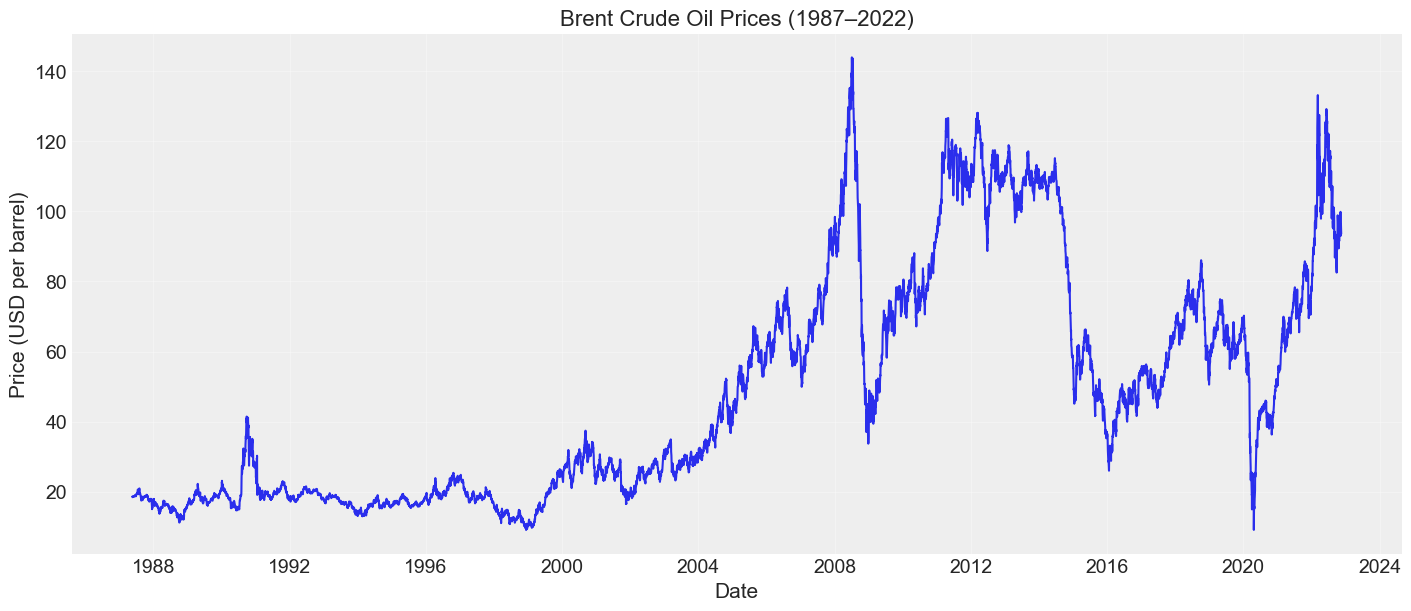

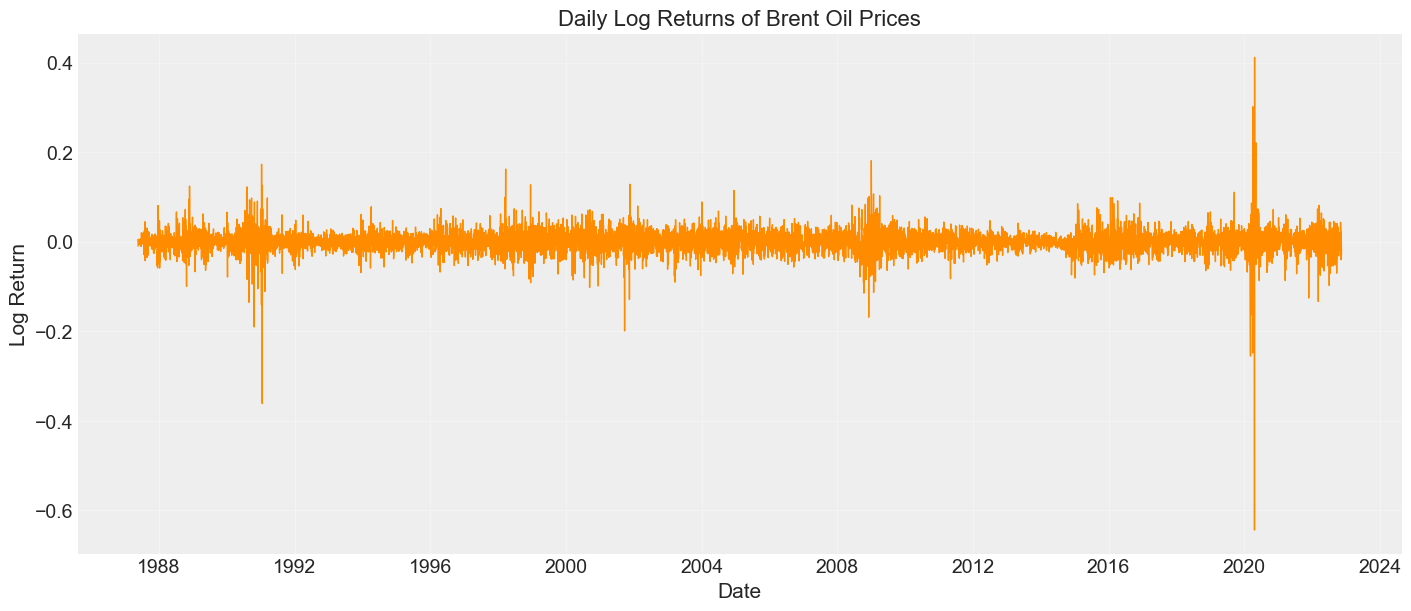


Running Augmented Dickey-Fuller tests:
Raw Price ADF: statistic=-1.9939, p-value=0.2893
Log Return ADF: statistic=-16.4271, p-value=0.0000

Monthly series has 427 observations.

Building and sampling Bayesian change point model...


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


c:\Users\mihre\Documents\KIAM\Week 11\Change Point Analysis and Statistical 
Modeling\venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1214 seconds.


✔ MCMC sampling complete!

Posterior summary:
          mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau    214.196  1.889  212.000  218.000      0.068    0.056     787.0   
mu1     21.515  1.321   19.033   23.923      0.023    0.020    3385.0   
mu2     75.688  1.291   73.269   78.120      0.022    0.020    3520.0   
sigma   18.568  0.627   17.414   19.762      0.009    0.010    4426.0   

       ess_tail  r_hat  
tau       598.0   1.01  
mu1      3137.0   1.00  
mu2      2714.0   1.00  
sigma    2997.0   1.00  


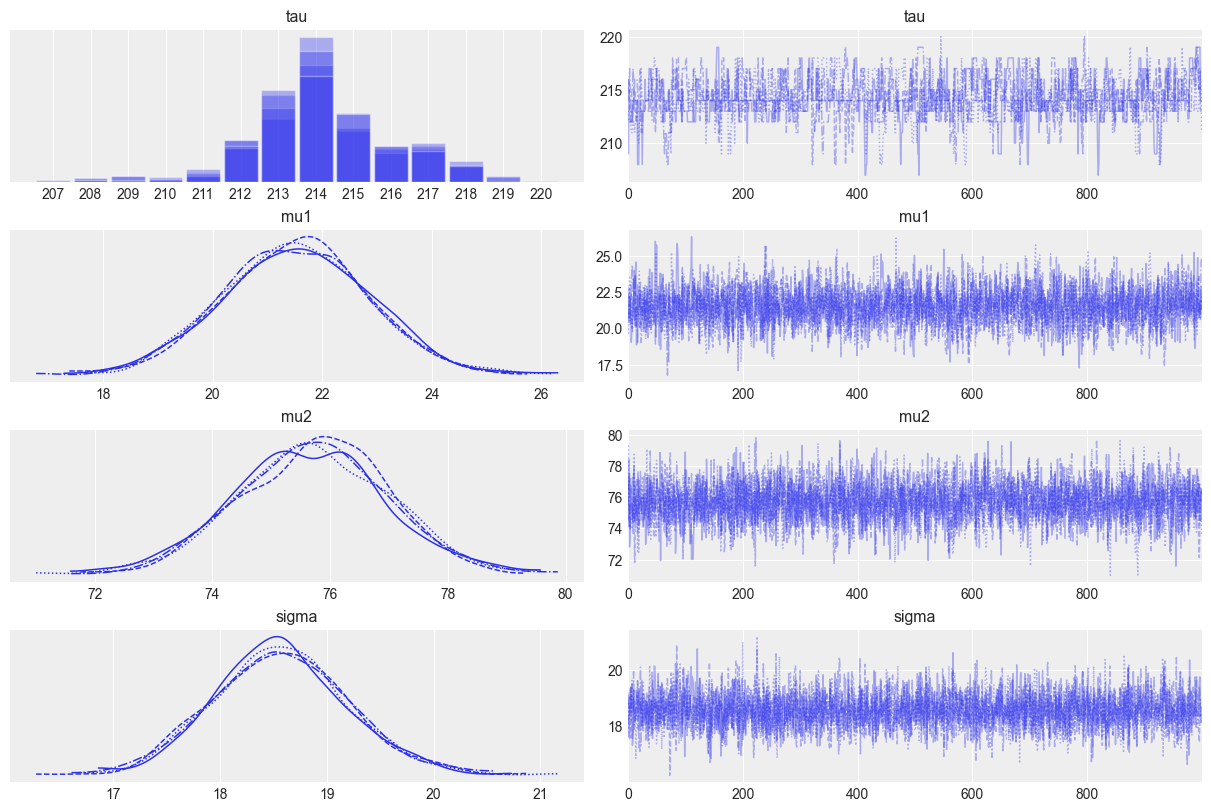

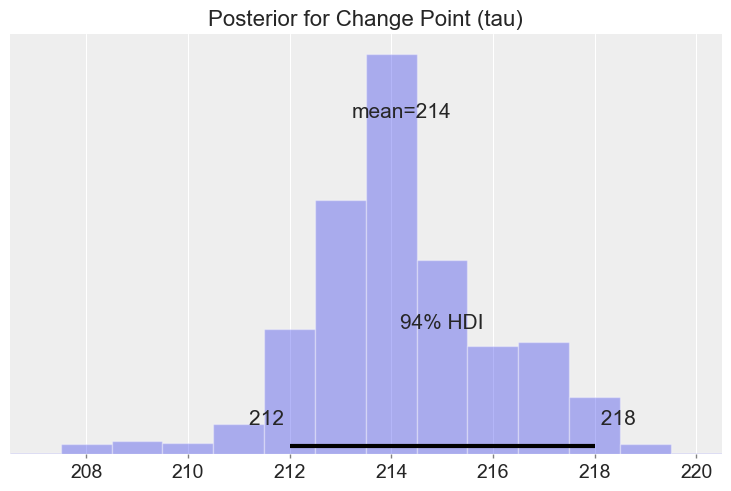


Estimated change point at index 214 → 2005-03-31


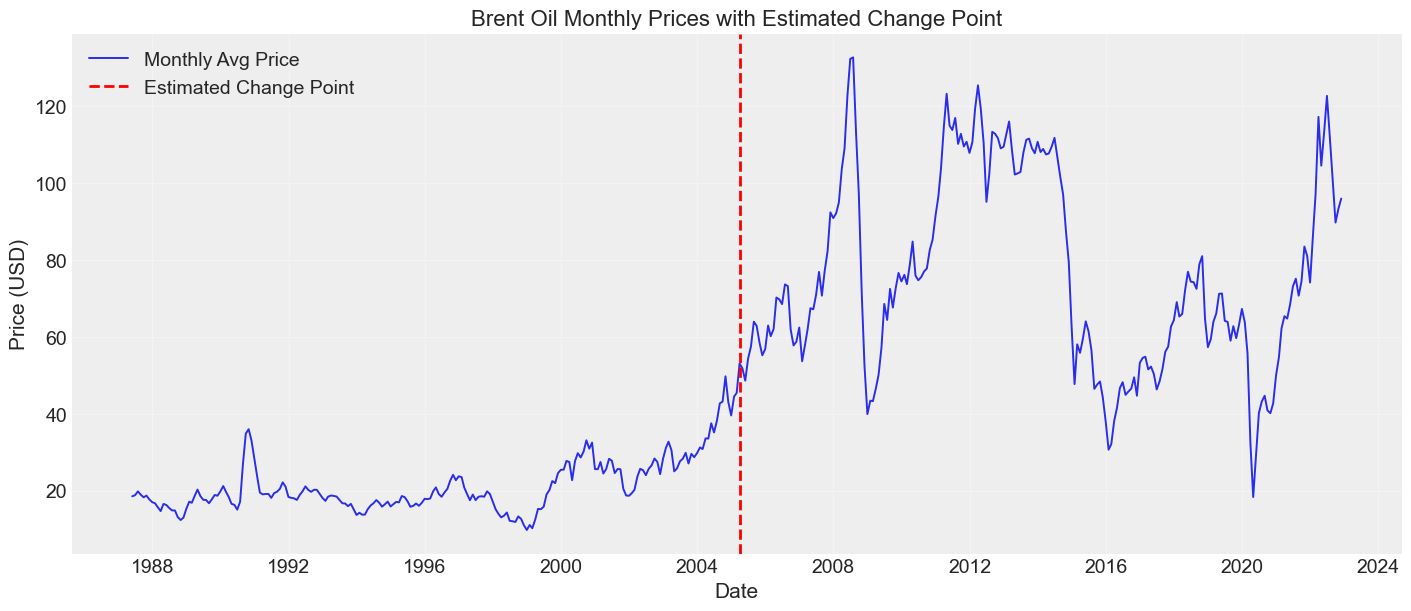


Events near the estimated change point (±30 days):


In [8]:
# === TASK 2 — CHANGE POINT MODELING & INSIGHT GENERATION ===

# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as tsa
import pymc as pm
import arviz as az
from datetime import timedelta

sns.set_style("whitegrid")
az.style.use("arviz-darkgrid")

# === 1️⃣ LOAD DATA ===
try:
    brent_df = pd.read_csv("../data/BrentOilPrices.csv", parse_dates=["Date"], dayfirst=True)
    events_df = pd.read_csv("../data/oil_events.csv", parse_dates=["Date"], dayfirst=True)
    print("✔ Data loaded successfully.")
except Exception as e:
    raise RuntimeError(f"Error loading data: {e}")

# Basic validation
if not {"Date", "Price"}.issubset(brent_df.columns):
    raise ValueError("BrentOilPrices.csv must include 'Date' and 'Price' columns.")

print("\nFirst 5 rows of price data:")
print(brent_df.head())
print("\nFirst 5 rows of event data:")
print(events_df.head())

# === 2️⃣ SORT & CLEAN ===
brent_df.sort_values("Date", inplace=True)
brent_df.reset_index(drop=True, inplace=True)

# === 3️⃣ EXPLORATORY DATA ANALYSIS ===
# Plot raw price series
plt.figure(figsize=(14,6))
plt.plot(brent_df["Date"], brent_df["Price"], linewidth=1.5)
plt.title("Brent Crude Oil Prices (1987–2022)")
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.grid(True, alpha=0.3)
plt.show()

# Compute log returns
brent_df["log_return"] = np.log(brent_df["Price"]) - np.log(brent_df["Price"].shift(1))
logret_df = brent_df.dropna(subset=["log_return"])

# Plot log returns
plt.figure(figsize=(14,6))
plt.plot(logret_df["Date"], logret_df["log_return"], color="darkorange", linewidth=1)
plt.title("Daily Log Returns of Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True, alpha=0.3)
plt.show()

# === 4️⃣ STATIONARITY TESTS ===
print("\nRunning Augmented Dickey-Fuller tests:")
adf_price = tsa.adfuller(brent_df["Price"].dropna())
print(f"Raw Price ADF: statistic={adf_price[0]:.4f}, p-value={adf_price[1]:.4f}")
adf_lr = tsa.adfuller(logret_df["log_return"])
print(f"Log Return ADF: statistic={adf_lr[0]:.4f}, p-value={adf_lr[1]:.4f}")

# === 5️⃣ AGGREGATE MONTHLY SERIES ===
monthly = (
    brent_df.set_index("Date")
            .resample("ME")["Price"]
            .mean()
            .dropna()
)
dates_monthly = monthly.index
prices_monthly = monthly.values
print(f"\nMonthly series has {len(prices_monthly)} observations.")

# === 6️⃣ BAYESIAN CHANGE POINT MODEL ===
print("\nBuilding and sampling Bayesian change point model...")
with pm.Model() as cp_model:
    n = len(prices_monthly)
    tau = pm.DiscreteUniform("tau", lower=0, upper=n - 1)
    mu1 = pm.Normal("mu1", mu=np.mean(prices_monthly), sigma=20)
    mu2 = pm.Normal("mu2", mu=np.mean(prices_monthly), sigma=20)
    sigma = pm.HalfNormal("sigma", sigma=10)
    idx = np.arange(n)
    mu = pm.math.switch(idx < tau, mu1, mu2)
    pm.Normal("obs", mu=mu, sigma=sigma, observed=prices_monthly)

    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True
    )

print("✔ MCMC sampling complete!")

# === 7️⃣ DIAGNOSTICS & POSTERIOR SUMMARY ===
print("\nPosterior summary:")
summary = az.summary(trace, var_names=["tau", "mu1", "mu2", "sigma"])
print(summary)

# Trace plots
az.plot_trace(trace, var_names=["tau", "mu1", "mu2", "sigma"])
plt.show()

# Posterior distribution for tau
az.plot_posterior(trace, var_names=["tau"])
plt.title("Posterior for Change Point (tau)")
plt.show()

# === 8️⃣ EXTRACT & VISUALIZE ESTIMATED CHANGE POINT ===
tau_samples = trace.posterior["tau"].values.flatten()
estimated_idx = int(np.median(tau_samples))
estimated_date = dates_monthly[estimated_idx]
print(f"\nEstimated change point at index {estimated_idx} → {estimated_date.date()}")

# Plot on series
plt.figure(figsize=(14,6))
plt.plot(dates_monthly, prices_monthly, label="Monthly Avg Price", linewidth=1.4)
plt.axvline(estimated_date, color="red", linestyle="--", linewidth=2, label="Estimated Change Point")
plt.title("Brent Oil Monthly Prices with Estimated Change Point")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# === 9️⃣ ASSOCIATE WITH EVENTS ===

# Ensure events are datetime
events_df["Date"] = pd.to_datetime(events_df["Date"], errors="coerce")

print("\nEvents near the estimated change point (±30 days):")
window = timedelta(days=30)

for _, row in events_df.iterrows():
    # Skip rows where Date failed to parse
    if pd.isna(row["Date"]):
        continue
    
    # Now both sides are datetime → subtraction works
    if abs(row["Date"] - estimated_date) <= window:
        print(f"⚠️ {row['Date'].date()}: {row['Event']} ({row['Category']})")

